# 4 - HistGradientBoosting (régression + classification)

Deuxième famille d'ensembles d'arbres, mais avec une philosophie opposée à la forêt :

- **Random Forest = bagging** : des centaines d'arbres indépendants votent, la moyenne lisse le bruit ;
- **Gradient Boosting = boosting** : les arbres sont construits **en séquence**, chacun corrige
  les **erreurs résiduelles** des précédents. C'est souvent l'état de l'art sur données tabulaires.

Je reste sur `HistGradientBoostingRegressor/Classifier` de sklearn (mon choix V1) plutôt que
XGBoost : c'est la même famille d'algorithmes (boosting de gradient sur histogrammes, comme
LightGBM), déjà optimisée, sans dépendance supplémentaire.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score

import outils_mspr as outils

## Réglage de l'early stopping — et sa limite, assumée

Le boosting peut sur-apprendre si on empile trop d'arbres. `early_stopping=True` surveille un
score sur 10 % du train et arrête quand ça stagne (`n_iter_no_change=10`) → le nombre d'arbres
est choisi automatiquement, comme en V1.

**Limite connue et assumée** : ce découpage interne de sklearn se fait **par lignes**, pas par
machine — des cycles d'une même machine se retrouvent des deux côtés, donc ce score interne est
un peu optimiste (fuite). sklearn ne permet pas de lui passer notre propre découpage. Ce n'est
pas grave tant qu'on le sait : ce score interne ne sert qu'à **arrêter l'empilement d'arbres**,
jamais à annoncer une performance. Toutes les performances annoncées viennent de NOTRE
validation par machine et du test officiel.

In [2]:
PARAMS_HGB = dict(
    random_state=outils.SEED,
    early_stopping=True,       # active la surveillance
    validation_fraction=0.1,   # 10 % du train mis de côté pour surveiller
    n_iter_no_change=10,       # arrête si pas d'amélioration sur 10 itérations
    max_iter=500,              # plafond large : c'est l'early stopping qui décide
)

## Usine 1

Comme en V1, je compare avec et sans `sample_weight` sur la zone à risque — mais cette fois
sur la **validation par machine**, pas sur le test.

In [3]:
App_U1, Val_U1, Test_U1, y_rul_vrai_U1, y_risk_vrai_U1, Features_U1 = outils.preparer_usine(1)

scaler_U1 = MinMaxScaler().fit(App_U1[Features_U1])
X_app_U1 = scaler_U1.transform(App_U1[Features_U1])
X_val_U1 = scaler_U1.transform(Val_U1[Features_U1])

proportion = App_U1['at_risk'].mean()
ratio_U1 = (1 - proportion) / proportion
poids_U1 = np.where(App_U1['at_risk'] == 1, ratio_U1, 1.0)

essais = {}
for avec_poids in [False, True]:
    hgb = HistGradientBoostingRegressor(**PARAMS_HGB)
    hgb.fit(X_app_U1, App_U1['RUL'], sample_weight=poids_U1 if avec_poids else None)
    pred = np.clip(hgb.predict(X_val_U1), 0, outils.RUL_MAX)
    rmse = np.sqrt(np.mean((Val_U1['RUL'] - pred) ** 2))
    nasa = outils.score_nasa(Val_U1['RUL'], pred) / Val_U1['machine_uid'].nunique()
    etiquette = 'avec poids risque' if avec_poids else 'sans poids'
    essais[etiquette] = (hgb, rmse, nasa)
    print(f"{etiquette:20s} → RMSE val : {rmse:5.2f} | NASA moyen val : {nasa:7.1f} "
          f"| arbres construits : {hgb.n_iter_}")

meilleur = min(essais, key=lambda k: essais[k][1])
hgb_rul_U1 = essais[meilleur][0]
print(f"\nConfig retenue : {meilleur}")

sans poids           → RMSE val : 15.89 | NASA moyen val :  1398.6 | arbres construits : 150


avec poids risque    → RMSE val : 16.43 | NASA moyen val :  1599.5 | arbres construits : 200

Config retenue : sans poids


In [4]:
# Classification : class_weight='balanced' fait le rééquilibrage tout seul (même ratio ~6.3)
hgb_risk_U1 = HistGradientBoostingClassifier(class_weight='balanced', **PARAMS_HGB)
hgb_risk_U1.fit(X_app_U1, App_U1['at_risk'])
print(f"F1 validation : {f1_score(Val_U1['at_risk'], hgb_risk_U1.predict(X_val_U1)):.3f} "
      f"| arbres construits : {hgb_risk_U1.n_iter_}")

F1 validation : 0.832 | arbres construits : 68


In [5]:
pred_risk_U1 = outils.evaluer_et_sauver('hgb', 1, scaler_U1, hgb_rul_U1, hgb_risk_U1,
                                        Features_U1, Test_U1, y_rul_vrai_U1, y_risk_vrai_U1)


===== Usine 1 — Régression RUL =====
 ---------- Resultat régression ----------
R² : 0.7984
MAE (erreur moyenne) : 13.99 cycles
RMSE (erreur écart-type) : 18.62 cycles
PHM08 Sûr (prédit trop tôt) : 480
PHM08 Dangereux (prédit trop tard) : 945
Score NASA total : 1425  (moyen par machine : 7.13)

===== Usine 1 — Classification at_risk =====
 ---------- Resultat classification ----------
Accuracy : 0.935
Precision (alertes justifiées) : 0.833
Recall (machines à risque détectées) : 0.889
F1 : 0.860
ROC-AUC : 0.986


## Usine 2

In [6]:
App_U2, Val_U2, Test_U2, y_rul_vrai_U2, y_risk_vrai_U2, Features_U2 = outils.preparer_usine(2)

scaler_U2 = MinMaxScaler().fit(App_U2[Features_U2])
X_app_U2 = scaler_U2.transform(App_U2[Features_U2])
X_val_U2 = scaler_U2.transform(Val_U2[Features_U2])

proportion = App_U2['at_risk'].mean()
ratio_U2 = (1 - proportion) / proportion
poids_U2 = np.where(App_U2['at_risk'] == 1, ratio_U2, 1.0)

# Régression — même décision poids/sans poids que sur l'Usine 1
hgb_rul_U2 = HistGradientBoostingRegressor(**PARAMS_HGB)
hgb_rul_U2.fit(X_app_U2, App_U2['RUL'],
               sample_weight=poids_U2 if meilleur == 'avec poids risque' else None)
pred_val = np.clip(hgb_rul_U2.predict(X_val_U2), 0, outils.RUL_MAX)
print(f"RMSE validation : {np.sqrt(np.mean((Val_U2['RUL'] - pred_val) ** 2)):.2f} cycles "
      f"| arbres construits : {hgb_rul_U2.n_iter_}")

hgb_risk_U2 = HistGradientBoostingClassifier(class_weight='balanced', **PARAMS_HGB)
hgb_risk_U2.fit(X_app_U2, App_U2['at_risk'])
print(f"F1 validation : {f1_score(Val_U2['at_risk'], hgb_risk_U2.predict(X_val_U2)):.3f} "
      f"| arbres construits : {hgb_risk_U2.n_iter_}")

RMSE validation : 15.71 cycles | arbres construits : 233


F1 validation : 0.822 | arbres construits : 115


In [7]:
pred_risk_U2 = outils.evaluer_et_sauver('hgb', 2, scaler_U2, hgb_rul_U2, hgb_risk_U2,
                                        Features_U2, Test_U2, y_rul_vrai_U2, y_risk_vrai_U2)


===== Usine 2 — Régression RUL =====
 ---------- Resultat régression ----------
R² : 0.7277
MAE (erreur moyenne) : 20.42 cycles
RMSE (erreur écart-type) : 28.29 cycles
PHM08 Sûr (prédit trop tôt) : 12459
PHM08 Dangereux (prédit trop tard) : 2656
Score NASA total : 15115  (moyen par machine : 29.81)

===== Usine 2 — Classification at_risk =====
 ---------- Resultat classification ----------
Accuracy : 0.925
Precision (alertes justifiées) : 0.764
Recall (machines à risque détectées) : 0.965
F1 : 0.853
ROC-AUC : 0.990


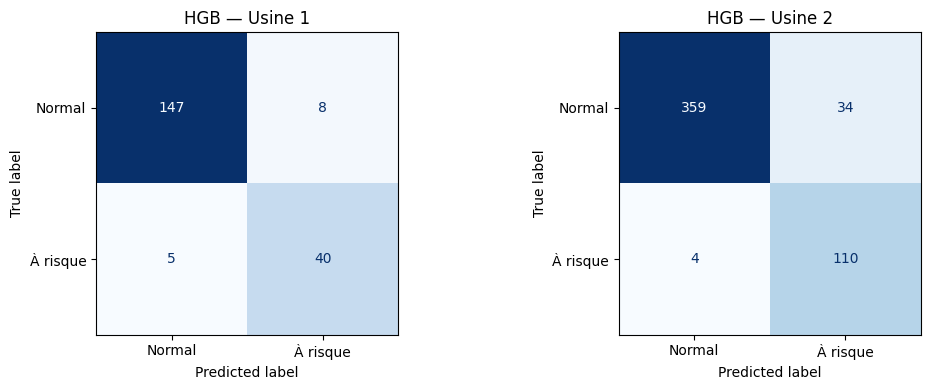

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (num, y_vrai, y_pred) in zip(axes, [(1, y_risk_vrai_U1, pred_risk_U1),
                                            (2, y_risk_vrai_U2, pred_risk_U2)]):
    cm = confusion_matrix(y_vrai, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Normal', 'À risque']).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'HGB — Usine {num}')
plt.tight_layout()
plt.savefig(outils.DOSSIER_FIGURES / 'hgb_confusion.png', dpi=120)
plt.show()

## Lecture et limites

- Le boosting affine généralement la forêt (les résidus sont corrigés arbre après arbre) ;
  le verdict chiffré est dans la synthèse (06).
- **Limites** : moins directement interprétable que la forêt (pas de `feature_importances_`
  natif sur la version histogramme — il faudrait une permutation importance) ; et comme tous
  les modèles tabulaires, il traite chaque cycle **isolément**, sans mémoire de la tendance.
- Le notebook 05 attaque exactement ce point avec un modèle de séquence (LSTM).